<a href="https://colab.research.google.com/github/TharinduLakshimal/robotic-hazard-detection/blob/30-epchos/Official_second_part.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install the Ultralytics library
!pip install ultralytics

# Mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.0 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
from ultralytics import YOLO

# 1. Paste the path to your last.pt file right here:
last_weights_path = '/content/drive/MyDrive/GlassDetection_Official/runs/glass_seg_clahe_30/weights/last.pt'

print(f"Loading weights from: {last_weights_path}")

# 2. Load the model from the saved weights
model_clahe = YOLO(last_weights_path)

# 3. Resume training!
# YOLO automatically reads your original settings (batch size, epochs, dataset path) from last.pt
print("Resuming training...")
results_clahe = model_clahe.train(resume=True)

print('✅ CLAHE Training Successfully Resumed and Completed!')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading weights from: /content/drive/MyDrive/GlassDetection_Official/runs/glass_seg_clahe_30/weights/last.pt
Resuming training...
Ultralytics 8.4.82 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/GlassDetection_Official/datasets/Vacuum-Hazard-Detection-v1-2-CLAHE/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=Non

In [3]:
from google.colab import drive
drive.mount('/content/drive')
import os
print('✅ Drive mounted')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted


In [4]:
!pip install ultralytics --quiet
import torch
print(f'GPU: {torch.cuda.get_device_name(0)}')

GPU: Tesla T4


In [6]:
import os
import shutil
from ultralytics import YOLO

# 1. Define your paths for this session
RUNS_DIR = '/content/drive/MyDrive/GlassDetection_Official/runs'
WEIGHTS_DIR = '/content/drive/MyDrive/GlassDetection_Official/weights'
clahe_yaml_path = '/content/drive/MyDrive/GlassDetection_Official/datasets/Vacuum-Hazard-Detection-v1-2-CLAHE/data.yaml'

os.makedirs(WEIGHTS_DIR, exist_ok=True)

# 2.4 Save CLAHE Best Weights
# Notice we use 'glass_seg_clahe_30' here to match your exact run folder
clahe_best_src = os.path.join(RUNS_DIR, 'glass_seg_clahe_30', 'weights', 'best.pt')
shutil.copy(clahe_best_src, os.path.join(WEIGHTS_DIR, 'best_clahe.pt'))
print('✅ CLAHE best weights saved to:', WEIGHTS_DIR)

# 2.5 Evaluate CLAHE Model on Test Set
print('\nStarting Evaluation...')
model_clahe = YOLO(os.path.join(WEIGHTS_DIR, 'best_clahe.pt'))

metrics_clahe = model_clahe.val(
    data    = clahe_yaml_path,
    split   = 'test',
    imgsz   = 640,
    device  = 0,
    plots   = True,
    project = RUNS_DIR,
    name    = 'eval_clahe'
)

print('\n=== CLAHE Model Test Results ===')
print(f'Mask mAP@50    : {metrics_clahe.seg.map50:.4f}')
print(f'Mask mAP@50-95 : {metrics_clahe.seg.map:.4f}')
print(f'Box  mAP@50    : {metrics_clahe.box.map50:.4f}')
print(f'Precision      : {metrics_clahe.seg.mp:.4f}')
print(f'Recall         : {metrics_clahe.seg.mr:.4f}')

# Save results to a dictionary for Phase 3
clahe_results = {
    'mask_map50'   : round(metrics_clahe.seg.map50, 4),
    'mask_map5095' : round(metrics_clahe.seg.map,   4),
    'box_map50'    : round(metrics_clahe.box.map50, 4),
    'precision'    : round(metrics_clahe.seg.mp,    4),
    'recall'       : round(metrics_clahe.seg.mr,    4)
}

✅ CLAHE best weights saved to: /content/drive/MyDrive/GlassDetection_Official/weights

Starting Evaluation...
Ultralytics 8.4.82 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,222,963 parameters, 0 gradients, 104.3 GFLOPs
val: Fast image access ✅ (ping: 0.9±0.3 ms, read: 0.1±0.0 MB/s, size: 55.6 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1R3aIHdYHPqNtSka0XaMebNOLm3nPE4Wj/GlassDetection_Official/datasets/Vacuum-Hazard-Detection-v1-2-CLAHE/test/labels... 390 images, 142 backgrounds, 162 corrupt: 100% ━━━━━━━━━━━━ 390/390 3.8it/s 1:42
val: /content/drive/.shortcut-targets-by-id/1R3aIHdYHPqNtSka0XaMebNOLm3nPE4Wj/GlassDetection_Official/datasets/Vacuum-Hazard-Detection-v1-2-CLAHE/test/images/bg_brown_black_002_frame_00001_jpg.rf.c55fdde9fa9bc66b03742349031329f4.jpg: ignoring corrupt image/label: Label class 1 exceeds dataset class count 1. Possible class labels are 0-0
val: /content/drive/.shortcut-targets-by-id/1R3a


📈 confusion_matrix.png


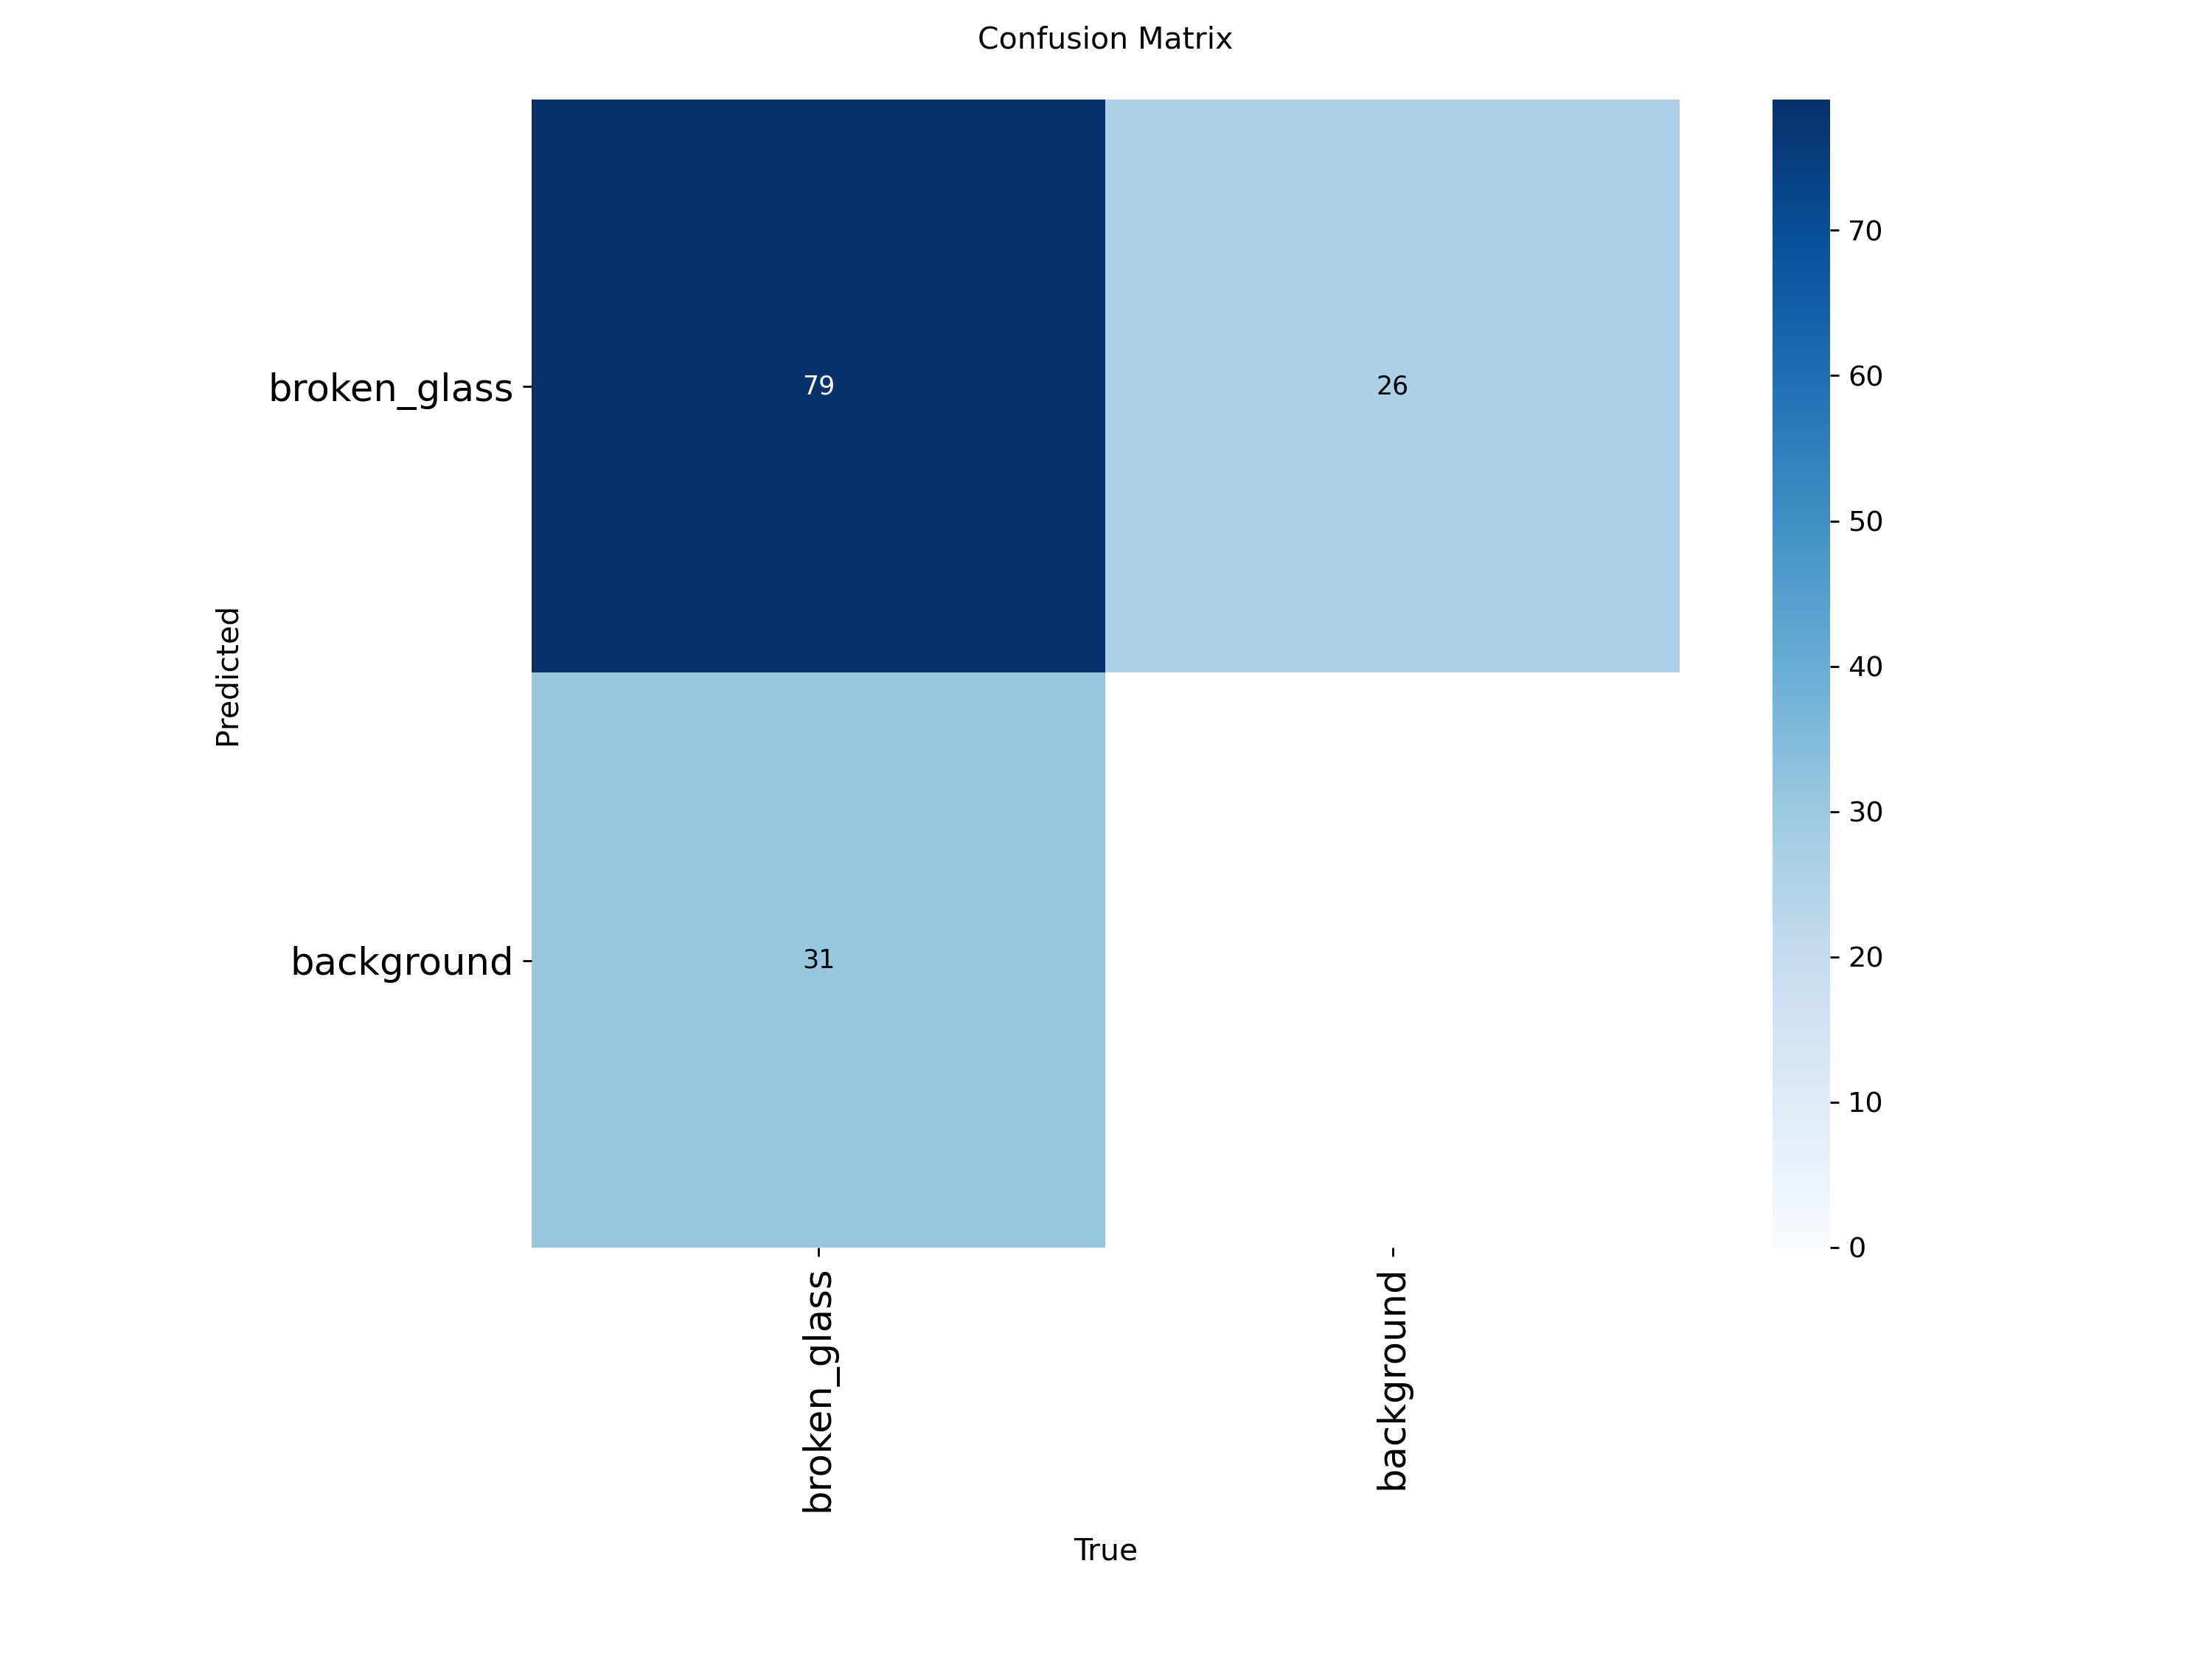


📈 confusion_matrix_normalized.png


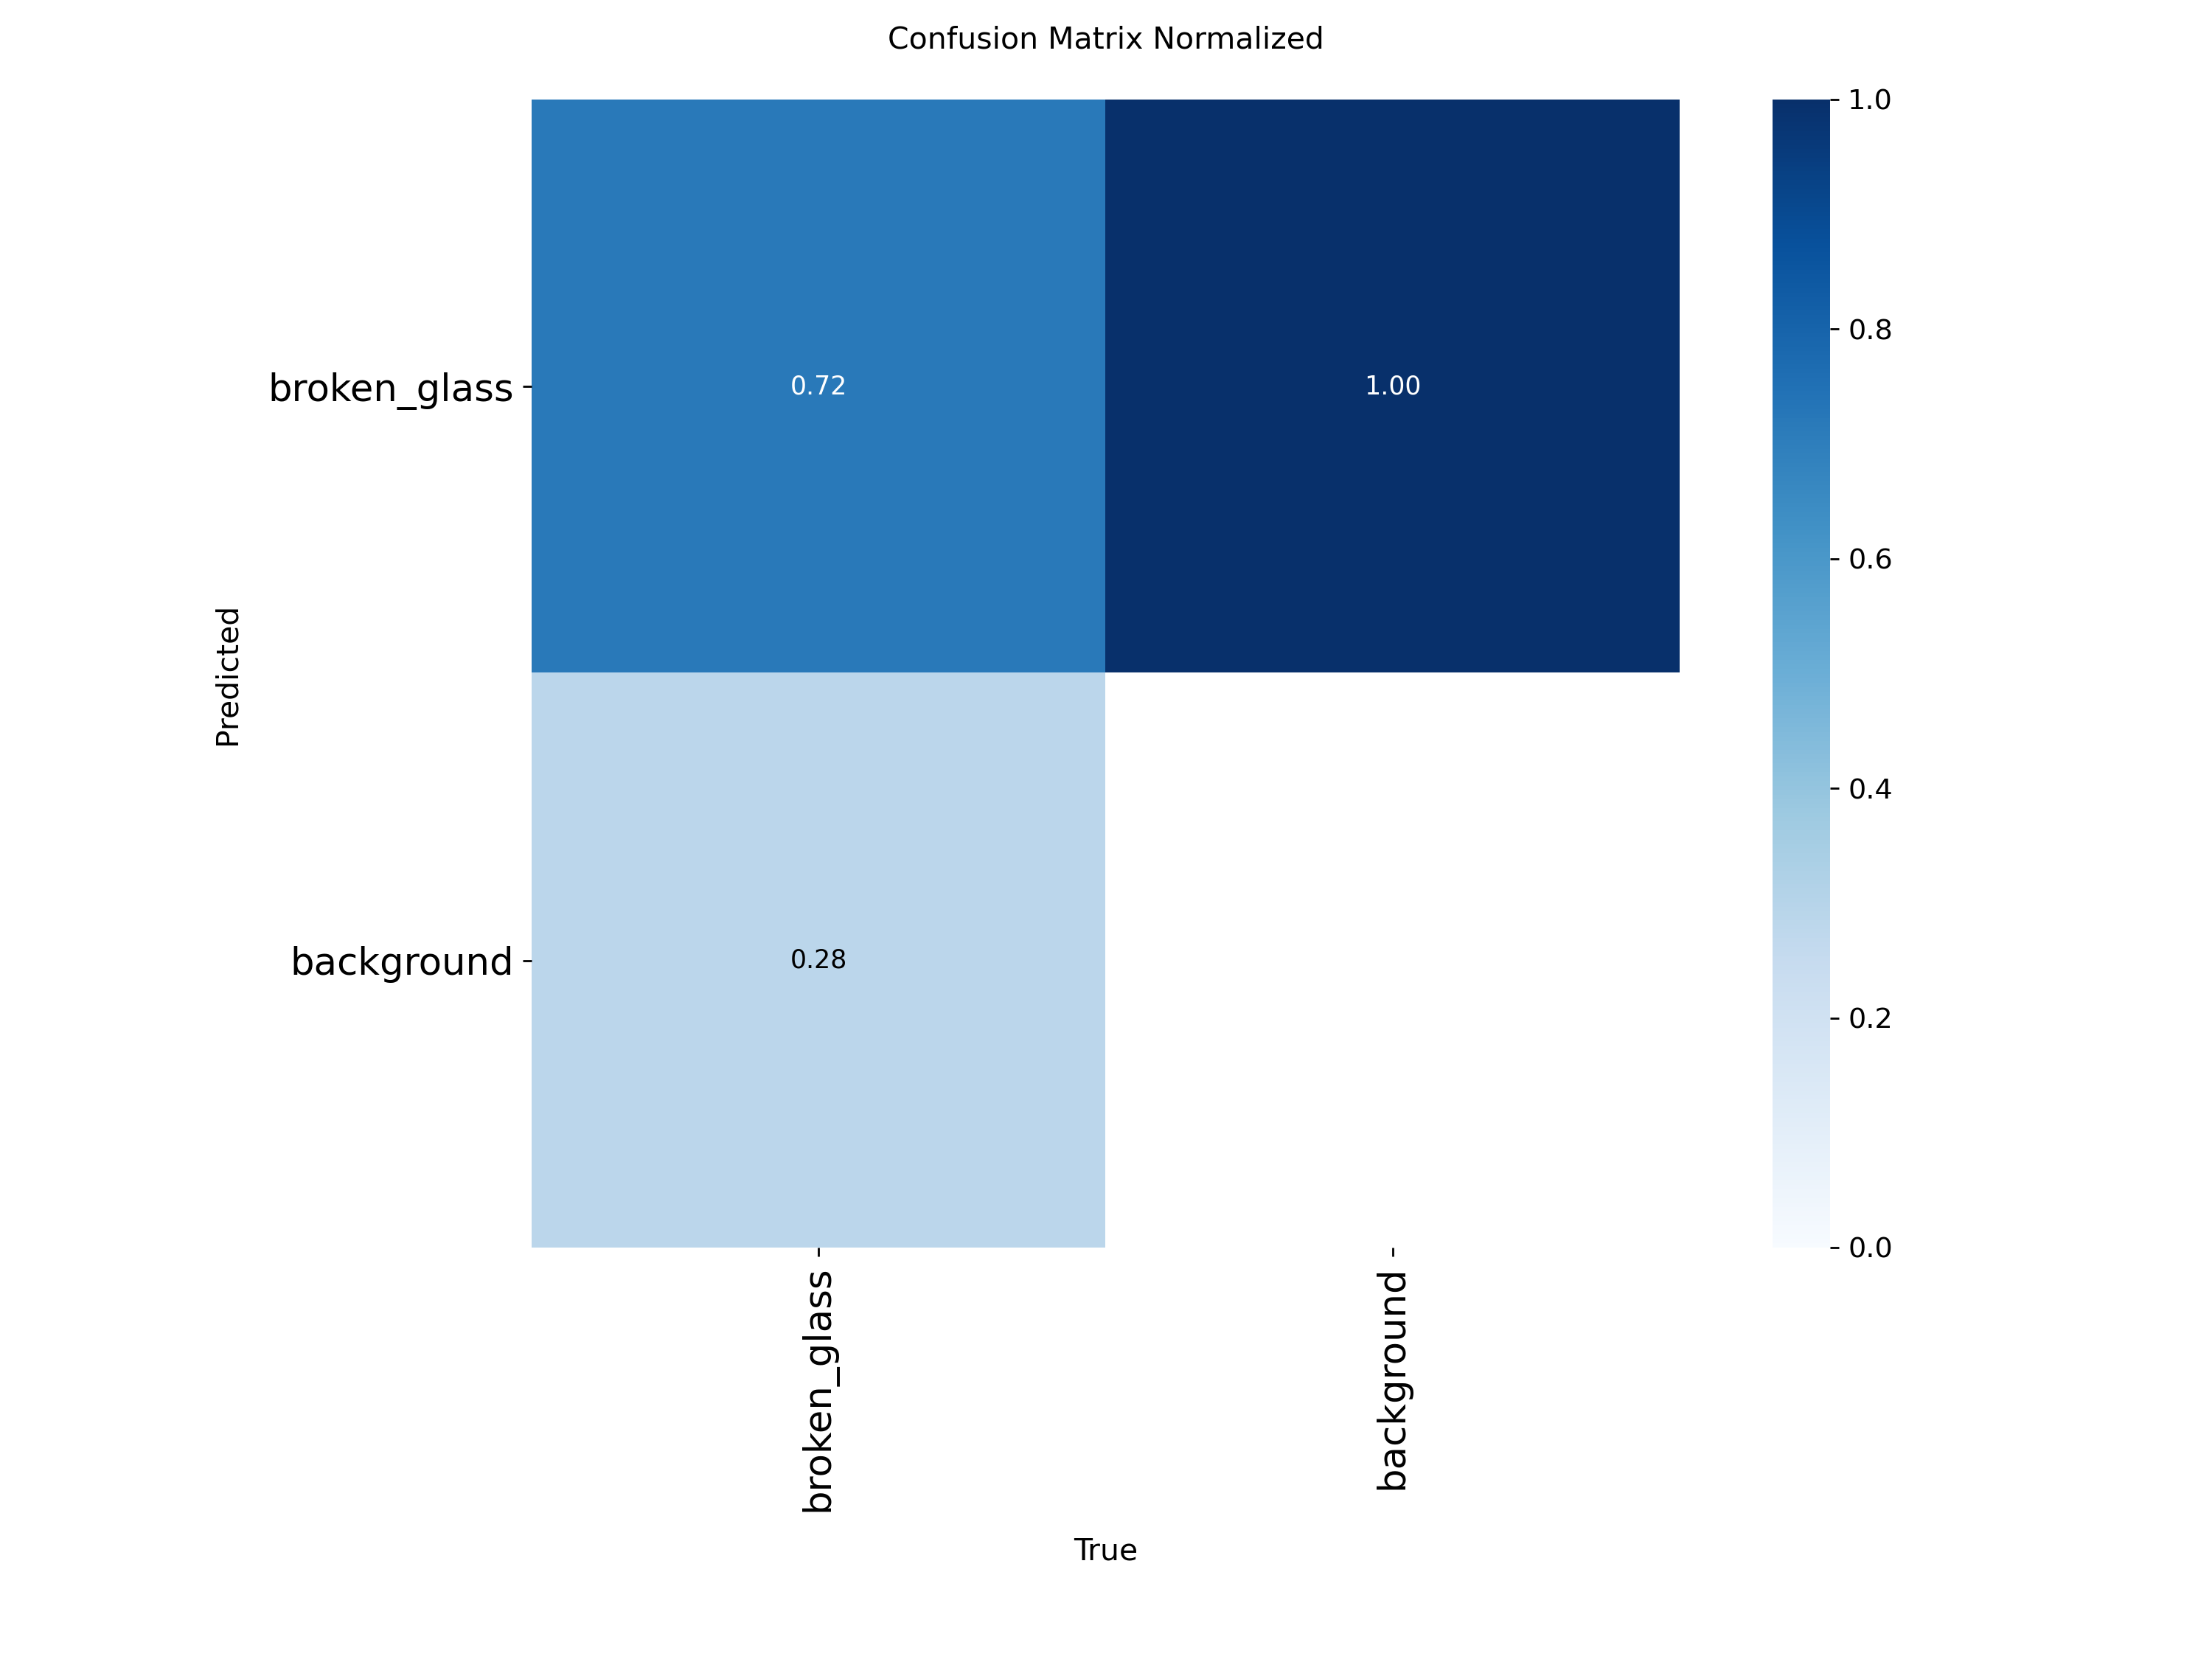

In [13]:
from IPython.display import Image as IPImage, display

plots_dir = os.path.join(RUNS_DIR, 'eval_no_clahe')

for plot in ['confusion_matrix.png', 'confusion_matrix_normalized.png',
             'PR_curve.png', 'F1_curve.png', 'P_curve.png', 'R_curve.png']:
    path = os.path.join(plots_dir, plot)
    if os.path.exists(path):
        print(f'\n📈 {plot}')
        display(IPImage(path, width=750))

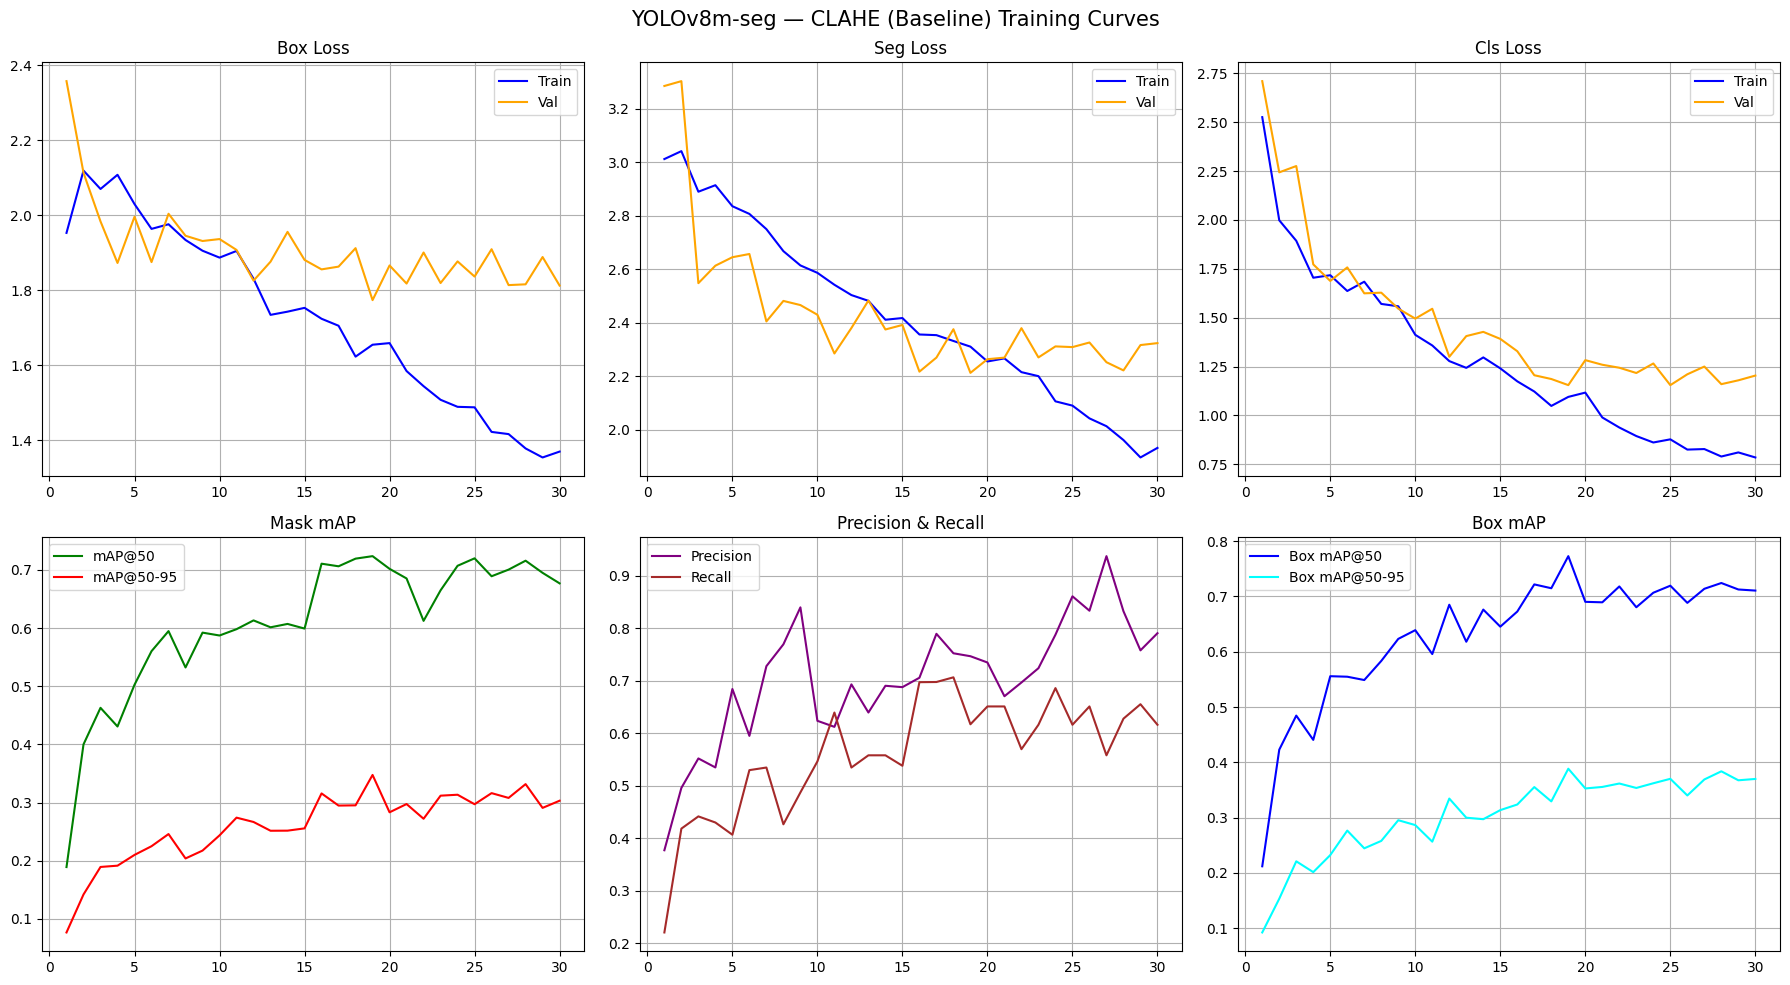

✅ Saved: /content/drive/MyDrive/GlassDetection_Official/runs/training_curves_no_clahe.png


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Define the missing variables so Colab knows where to look!
RUNS_DIR = '/content/drive/MyDrive/GlassDetection_Official/runs'
RUN_NAME = 'glass_seg_clahe_30'  # Your No CLAHE baseline folder

# 2. Load the CSV
csv_path = os.path.join(RUNS_DIR, RUN_NAME, 'results.csv')
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

# 3. Plot the training curves
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('YOLOv8m-seg — CLAHE (Baseline) Training Curves', fontsize=15)

axes[0,0].plot(df['epoch'], df['train/box_loss'], label='Train', color='blue')
axes[0,0].plot(df['epoch'], df['val/box_loss'],   label='Val',   color='orange')
axes[0,0].set_title('Box Loss'); axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(df['epoch'], df['train/seg_loss'], label='Train', color='blue')
axes[0,1].plot(df['epoch'], df['val/seg_loss'],   label='Val',   color='orange')
axes[0,1].set_title('Seg Loss'); axes[0,1].legend(); axes[0,1].grid(True)

axes[0,2].plot(df['epoch'], df['train/cls_loss'], label='Train', color='blue')
axes[0,2].plot(df['epoch'], df['val/cls_loss'],   label='Val',   color='orange')
axes[0,2].set_title('Cls Loss'); axes[0,2].legend(); axes[0,2].grid(True)

axes[1,0].plot(df['epoch'], df['metrics/mAP50(M)'],    label='mAP@50',    color='green')
axes[1,0].plot(df['epoch'], df['metrics/mAP50-95(M)'], label='mAP@50-95', color='red')
axes[1,0].set_title('Mask mAP'); axes[1,0].legend(); axes[1,0].grid(True)

axes[1,1].plot(df['epoch'], df['metrics/precision(M)'], label='Precision', color='purple')
axes[1,1].plot(df['epoch'], df['metrics/recall(M)'],    label='Recall',    color='brown')
axes[1,1].set_title('Precision & Recall'); axes[1,1].legend(); axes[1,1].grid(True)

axes[1,2].plot(df['epoch'], df['metrics/mAP50(B)'],    label='Box mAP@50',    color='blue')
axes[1,2].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='Box mAP@50-95', color='cyan')
axes[1,2].set_title('Box mAP'); axes[1,2].legend(); axes[1,2].grid(True)

plt.tight_layout()
save_path = os.path.join(RUNS_DIR, 'training_curves_no_clahe.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {save_path}')

=== ABLATION STUDY — CLAHE vs No CLAHE ===

        Metric  No CLAHE  With CLAHE  Improvement Better Model
   Mask mAP@50    0.6599      0.6320      -0.0279   ❌ Baseline
Mask mAP@50-95    0.2909      0.2891      -0.0018   ❌ Baseline
    Box mAP@50    0.7092      0.6350      -0.0742   ❌ Baseline
     Precision    0.6860      0.7003       0.0143      ✅ CLAHE
        Recall    0.6554      0.6160      -0.0394   ❌ Baseline

✅ Saved Table: /content/drive/MyDrive/GlassDetection_Official/runs/ablation_comparison.csv


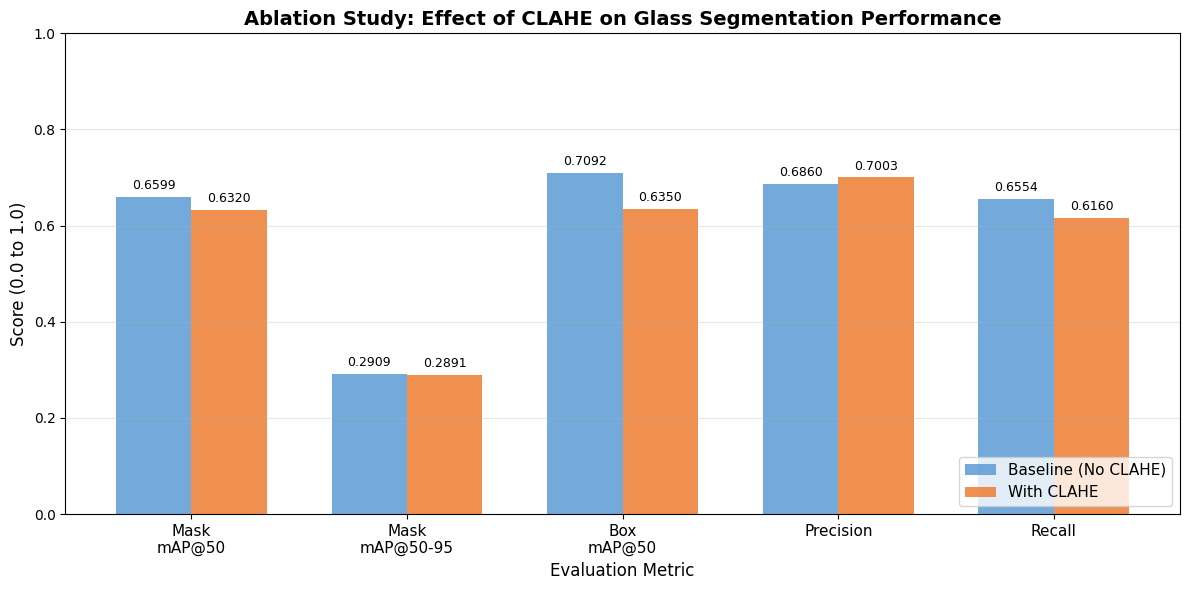

✅ Saved Chart: /content/drive/MyDrive/GlassDetection_Official/runs/ablation_chart.png


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Set your runs directory
RUNS_DIR = '/content/drive/MyDrive/GlassDetection_Official/runs'
os.makedirs(RUNS_DIR, exist_ok=True)

# 1. Input the actual results provided
no_clahe_results = {
    'mask_map50'   : 0.6599,
    'mask_map5095' : 0.2909,
    'box_map50'    : 0.7092,
    'precision'    : 0.6860,
    'recall'       : 0.6554
}

clahe_results = {
    'mask_map50'   : 0.6320,
    'mask_map5095' : 0.2891,
    'box_map50'    : 0.6350,
    'precision'    : 0.7003,
    'recall'       : 0.6160
}

# 2. Side-by-Side Comparison Table
comparison = pd.DataFrame({
    'Metric'      : ['Mask mAP@50', 'Mask mAP@50-95', 'Box mAP@50', 'Precision', 'Recall'],
    'No CLAHE'    : [no_clahe_results['mask_map50'],
                     no_clahe_results['mask_map5095'],
                     no_clahe_results['box_map50'],
                     no_clahe_results['precision'],
                     no_clahe_results['recall']],
    'With CLAHE'  : [clahe_results['mask_map50'],
                     clahe_results['mask_map5095'],
                     clahe_results['box_map50'],
                     clahe_results['precision'],
                     clahe_results['recall']]
})

# Calculate the difference
comparison['Improvement'] = (
    comparison['With CLAHE'] - comparison['No CLAHE']
).round(4)

# Determine which was better
comparison['Better Model'] = comparison['Improvement'].apply(
    lambda x: '✅ CLAHE' if x > 0 else '❌ Baseline'
)

print('=== ABLATION STUDY — CLAHE vs No CLAHE ===\n')
print(comparison.to_string(index=False))

# Save CSV
csv_path = os.path.join(RUNS_DIR, 'ablation_comparison.csv')
comparison.to_csv(csv_path, index=False)
print(f'\n✅ Saved Table: {csv_path}')


# 3. Ablation Bar Chart
metrics_labels = ['Mask\nmAP@50', 'Mask\nmAP@50-95', 'Box\nmAP@50', 'Precision', 'Recall']
no_clahe_vals  = [no_clahe_results['mask_map50'], no_clahe_results['mask_map5095'],
                  no_clahe_results['box_map50'],  no_clahe_results['precision'],
                  no_clahe_results['recall']]
clahe_vals     = [clahe_results['mask_map50'],   clahe_results['mask_map5095'],
                  clahe_results['box_map50'],     clahe_results['precision'],
                  clahe_results['recall']]

x     = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
# Using a clean color scheme: Blue for Baseline, Orange for CLAHE
bars1 = ax.bar(x - width/2, no_clahe_vals, width, label='Baseline (No CLAHE)', color='#5B9BD5', alpha=0.85)
bars2 = ax.bar(x + width/2, clahe_vals,    width, label='With CLAHE',          color='#ED7D31', alpha=0.85)

ax.set_xlabel('Evaluation Metric', fontsize=12)
ax.set_ylabel('Score (0.0 to 1.0)', fontsize=12)
ax.set_title('Ablation Study: Effect of CLAHE on Glass Segmentation Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=11)

# Move legend outside the plot slightly so it doesn't overlap bars
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

# Add exact value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
save_path = os.path.join(RUNS_DIR, 'ablation_chart.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved Chart: {save_path}')

In [8]:
import os
import shutil

# Updated to GlassDetection_Official
BASE       = '/content/drive/MyDrive/GlassDetection_Official/datasets/Vacuum-Hazard-Detection-v1-2'
TEST_IMG   = os.path.join(BASE, 'test/images')
TEST_LBL   = os.path.join(BASE, 'test/labels')
SPLIT_BASE = '/content/drive/MyDrive/GlassDetection_Official/test_splits'

def get_glass_type(name):
    name = name.lower()
    if 'bulb'   in name or 'clean' in name: return 'clear_transparent'
    if 'mirror' in name:                    return 'clear_reflective'
    if 'green'  in name or 'brown' in name: return 'colored'
    return 'unknown'

def get_floor_type(name):
    name = name.lower()
    if 'ciment' in name:                    return 'cement'
    if 'black_floor' in name:               return 'carpet'
    if any(f in name for f in ['green_floor','white_floor',
           'light_brown_black_tile','gray_black_tile']): return 'tile'
    return 'unknown'

groups = {}

for fname in os.listdir(TEST_IMG):
    if not fname.lower().endswith(('.jpg','.jpeg','.png')):
        continue
    stem  = os.path.splitext(fname)[0]
    glass = get_glass_type(stem)
    floor = get_floor_type(stem)

    if glass == 'unknown' or floor == 'unknown':
        continue

    key = f'{glass}__{floor}'
    groups.setdefault(key, []).append(stem)

    # Copy image
    dst_img = os.path.join(SPLIT_BASE, key, 'images')
    os.makedirs(dst_img, exist_ok=True)
    shutil.copy(os.path.join(TEST_IMG, fname),
                os.path.join(dst_img, fname))

    # Copy label
    lbl = os.path.join(TEST_LBL, stem + '.txt')
    if os.path.exists(lbl):
        dst_lbl = os.path.join(SPLIT_BASE, key, 'labels')
        os.makedirs(dst_lbl, exist_ok=True)
        shutil.copy(lbl, os.path.join(dst_lbl, stem + '.txt'))

print('✅ Groups created:\n')
for key, files in sorted(groups.items()):
    print(f'  {key:35} → {len(files):4} images')

✅ Groups created:

  clear_reflective__carpet            →    5 images
  clear_reflective__cement            →   35 images
  clear_reflective__tile              →   40 images
  clear_transparent__carpet           →   15 images
  clear_transparent__cement           →   50 images
  clear_transparent__tile             →   60 images
  colored__carpet                     →   10 images
  colored__cement                     →   55 images
  colored__tile                       →   60 images


In [9]:
from ultralytics import YOLO
import os

RUNS_DIR = '/content/drive/MyDrive/GlassDetection_Official/runs'
SPLIT_BASE = '/content/drive/MyDrive/GlassDetection_Official/test_splits'

# Using the Baseline model since it won the Ablation Study for overall mAP
BEST_MODEL = '/content/drive/MyDrive/GlassDetection_Official/runs/glass_seg_v1_30/weights/best.pt'

print(f"Loading model from: {BEST_MODEL}")
model = YOLO(BEST_MODEL)

group_results = {}

for group in sorted(os.listdir(SPLIT_BASE)):
    img_dir = os.path.join(SPLIT_BASE, group, 'images')
    if not os.path.exists(img_dir):
        continue

    count = len(os.listdir(img_dir))
    if count == 0:
        continue

    print(f'\n🔍 Running inference: {group} ({count} images)...')

    preds = model.predict(
        source  = img_dir,
        imgsz   = 640,
        conf    = 0.25,
        save    = True,
        project = RUNS_DIR,
        name    = f'inference_{group}',
        verbose = False
    )

    # Count total detections across all images in this group
    total_detections = sum(len(r.boxes) for r in preds)

    group_results[group] = {
        'images'     : count,
        'detections' : total_detections,
        'avg_per_img': round(total_detections / count, 2)
    }
    print(f'  ✅ {total_detections} detections across {count} images')

print('\n✅ All inference groups done!')

Loading model from: /content/drive/MyDrive/GlassDetection_Official/runs/glass_seg_v1_30/weights/best.pt

🔍 Running inference: clear_reflective__carpet (5 images)...
Results saved to /content/drive/.shortcut-targets-by-id/1R3aIHdYHPqNtSka0XaMebNOLm3nPE4Wj/GlassDetection_Official/runs/inference_clear_reflective__carpet
  ✅ 1 detections across 5 images

🔍 Running inference: clear_reflective__cement (35 images)...
Results saved to /content/drive/.shortcut-targets-by-id/1R3aIHdYHPqNtSka0XaMebNOLm3nPE4Wj/GlassDetection_Official/runs/inference_clear_reflective__cement
  ✅ 32 detections across 35 images

🔍 Running inference: clear_reflective__tile (40 images)...
Results saved to /content/drive/.shortcut-targets-by-id/1R3aIHdYHPqNtSka0XaMebNOLm3nPE4Wj/GlassDetection_Official/runs/inference_clear_reflective__tile
  ✅ 6 detections across 40 images

🔍 Running inference: clear_transparent__carpet (15 images)...
Results saved to /content/drive/.shortcut-targets-by-id/1R3aIHdYHPqNtSka0XaMebNOLm3nPE4W


=== PER GROUP DETECTION RESULTS ===

       Glass Type Floor Type  Images  Total Detections  Avg per Image
 clear_reflective     carpet       5                 1           0.20
clear_transparent     carpet      15                 0           0.00
          colored     carpet      10                 1           0.10
 clear_reflective     cement      35                32           0.91
clear_transparent     cement      50                34           0.68
          colored     cement      55                34           0.62
 clear_reflective       tile      40                 6           0.15
clear_transparent       tile      60                 4           0.07
          colored       tile      60                16           0.27

✅ Saved Table: /content/drive/MyDrive/GlassDetection_Official/runs/per_group_results.csv


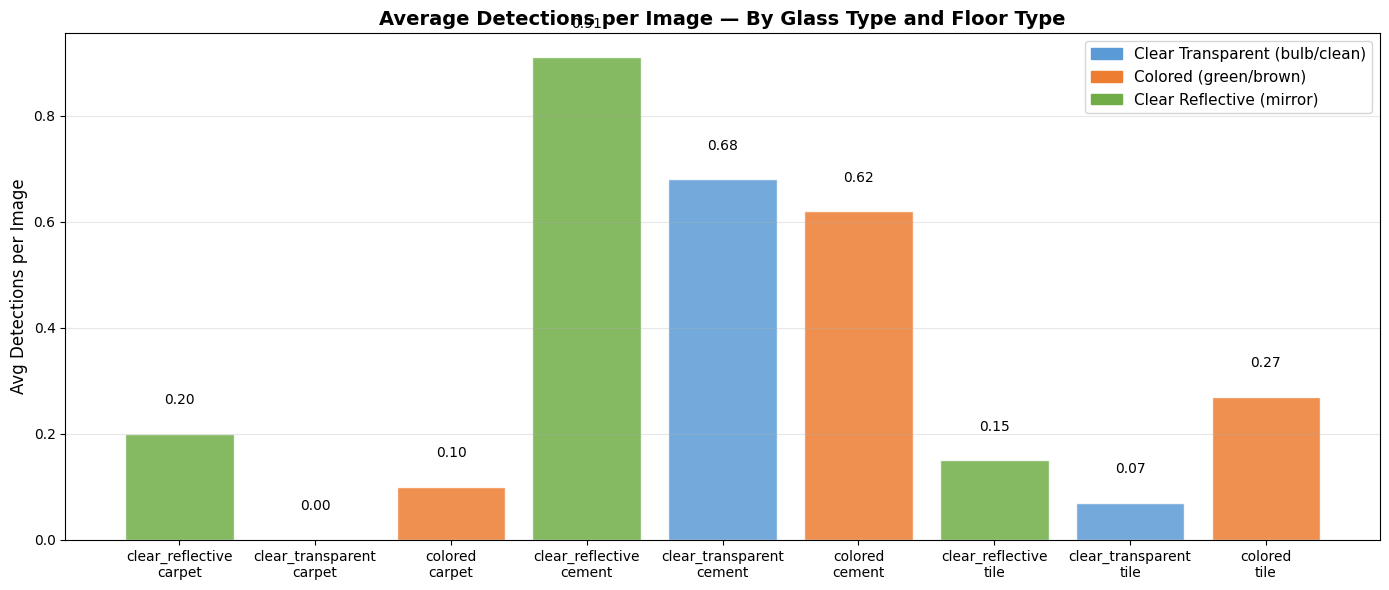

✅ Saved Chart: /content/drive/MyDrive/GlassDetection_Official/runs/per_group_chart.png


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import os

RUNS_DIR = '/content/drive/MyDrive/GlassDetection_Official/runs'

rows = []
for group, r in group_results.items():
    glass, floor = group.split('__')
    rows.append({
        'Glass Type'       : glass,
        'Floor Type'       : floor,
        'Images'           : r['images'],
        'Total Detections' : r['detections'],
        'Avg per Image'    : r['avg_per_img']
    })

df = pd.DataFrame(rows).sort_values(['Floor Type', 'Glass Type'])
print('\n=== PER GROUP DETECTION RESULTS ===\n')
print(df.to_string(index=False))

csv_path = os.path.join(RUNS_DIR, 'per_group_results.csv')
df.to_csv(csv_path, index=False)
print(f'\n✅ Saved Table: {csv_path}')

# Chart Generation
fig, ax = plt.subplots(figsize=(14, 6))
labels = [f"{r['Glass Type']}\n{r['Floor Type']}" for _, r in df.iterrows()]
values = df['Avg per Image'].tolist()

# Color-coding based on Glass Type
colors = ['#5B9BD5' if 'clear_transparent' in l else
          '#ED7D31' if 'colored' in l else '#70AD47' for l in labels]

bars = ax.bar(labels, values, color=colors, alpha=0.85, edgecolor='white')
ax.set_title('Average Detections per Image — By Glass Type and Floor Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Detections per Image', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Add numeric labels on bars
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)

from matplotlib.patches import Patch
legend = [Patch(color='#5B9BD5', label='Clear Transparent (bulb/clean)'),
          Patch(color='#ED7D31', label='Colored (green/brown)'),
          Patch(color='#70AD47', label='Clear Reflective (mirror)')]
ax.legend(handles=legend, fontsize=11)

plt.tight_layout()
save_path = os.path.join(RUNS_DIR, 'per_group_chart.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved Chart: {save_path}')

In [11]:
import pandas as pd
import json
import os

RUNS_DIR = '/content/drive/MyDrive/GlassDetection_Official/runs'

# Hardcoding the results from Phase 3 so the script has them in memory
no_clahe_results = {
    'mask_map50'   : 0.6599,
    'mask_map5095' : 0.2909,
    'box_map50'    : 0.7092,
    'precision'    : 0.6860,
    'recall'       : 0.6554
}

clahe_results = {
    'mask_map50'   : 0.6320,
    'mask_map5095' : 0.2891,
    'box_map50'    : 0.6350,
    'precision'    : 0.7003,
    'recall'       : 0.6160
}

summary = {
    'Model A — No CLAHE (Baseline)' : no_clahe_results,
    'Model B — With CLAHE'          : clahe_results
}

print('=' * 60)
print('FINAL RESULTS SUMMARY — Glass-Floor-2026')
print('=' * 60)

for model_name, results in summary.items():
    print(f'\n{model_name}')
    print(f"  Mask mAP@50    : {results['mask_map50']}")
    print(f"  Mask mAP@50-95 : {results['mask_map5095']}")
    print(f"  Box  mAP@50    : {results['box_map50']}")
    print(f"  Precision      : {results['precision']}")
    print(f"  Recall         : {results['recall']}")

# Save as JSON for records
json_path = os.path.join(RUNS_DIR, 'final_results.json')
with open(json_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'\n✅ All results saved: {json_path}')

FINAL RESULTS SUMMARY — Glass-Floor-2026

Model A — No CLAHE (Baseline)
  Mask mAP@50    : 0.6599
  Mask mAP@50-95 : 0.2909
  Box  mAP@50    : 0.7092
  Precision      : 0.686
  Recall         : 0.6554

Model B — With CLAHE
  Mask mAP@50    : 0.632
  Mask mAP@50-95 : 0.2891
  Box  mAP@50    : 0.635
  Precision      : 0.7003
  Recall         : 0.616

✅ All results saved: /content/drive/MyDrive/GlassDetection_Official/runs/final_results.json


Loading model for visualization: /content/drive/MyDrive/GlassDetection_Official/runs/glass_seg_v1_30/weights/best.pt
Results saved to /content/drive/.shortcut-targets-by-id/1R3aIHdYHPqNtSka0XaMebNOLm3nPE4Wj/GlassDetection_Official/runs/figure_clear_reflective__carpet

📸 Group: clear_reflective__carpet


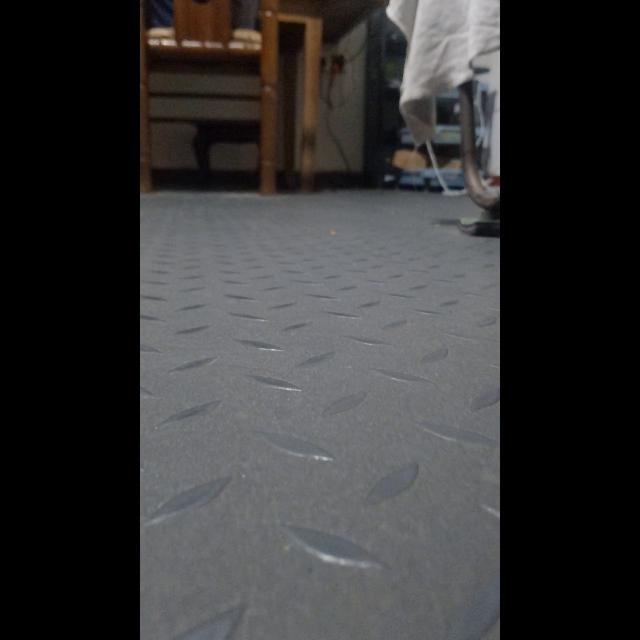

Results saved to /content/drive/.shortcut-targets-by-id/1R3aIHdYHPqNtSka0XaMebNOLm3nPE4Wj/GlassDetection_Official/runs/figure_clear_reflective__cement

📸 Group: clear_reflective__cement


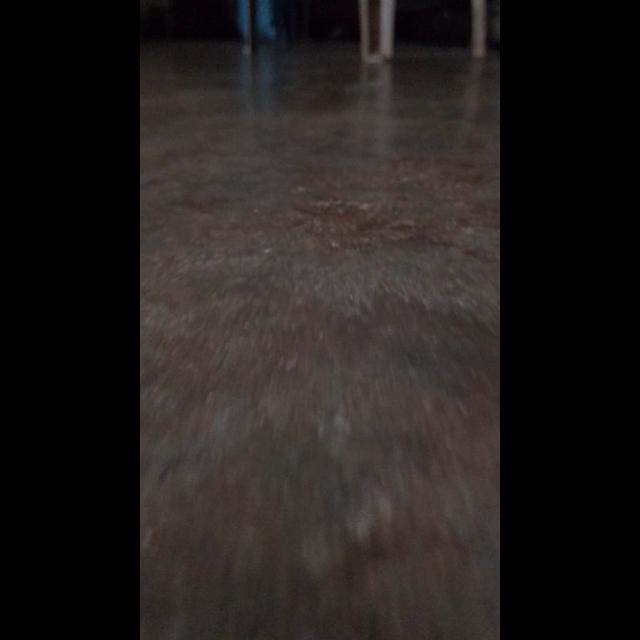

Results saved to /content/drive/.shortcut-targets-by-id/1R3aIHdYHPqNtSka0XaMebNOLm3nPE4Wj/GlassDetection_Official/runs/figure_clear_reflective__tile

📸 Group: clear_reflective__tile


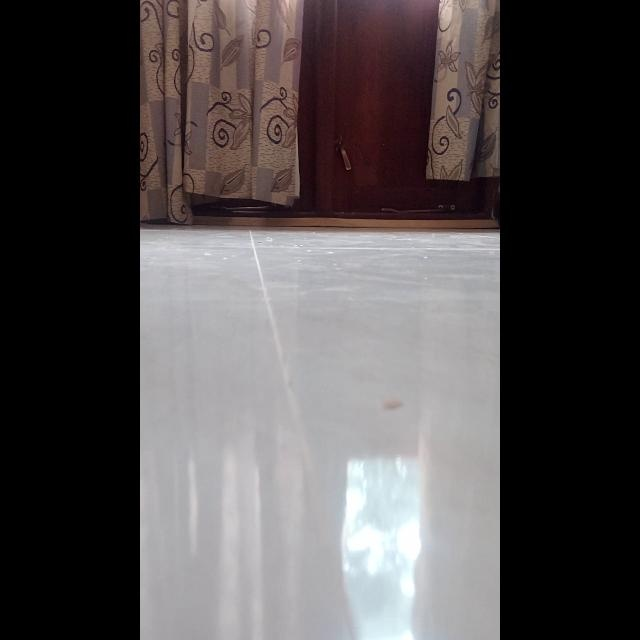

Results saved to /content/drive/.shortcut-targets-by-id/1R3aIHdYHPqNtSka0XaMebNOLm3nPE4Wj/GlassDetection_Official/runs/figure_clear_transparent__carpet

📸 Group: clear_transparent__carpet


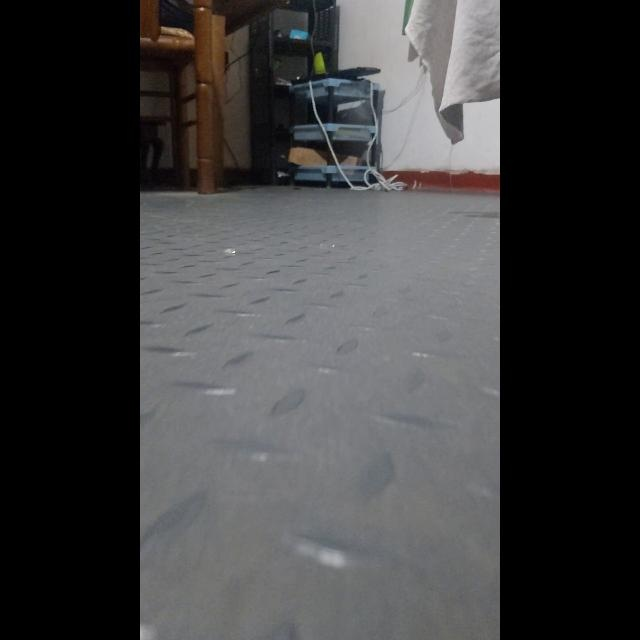

Results saved to /content/drive/.shortcut-targets-by-id/1R3aIHdYHPqNtSka0XaMebNOLm3nPE4Wj/GlassDetection_Official/runs/figure_clear_transparent__cement

📸 Group: clear_transparent__cement


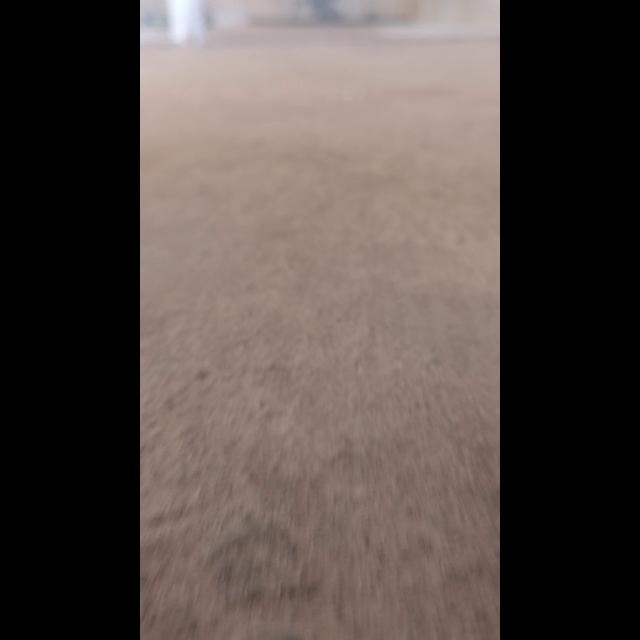

Results saved to /content/drive/.shortcut-targets-by-id/1R3aIHdYHPqNtSka0XaMebNOLm3nPE4Wj/GlassDetection_Official/runs/figure_clear_transparent__tile

📸 Group: clear_transparent__tile


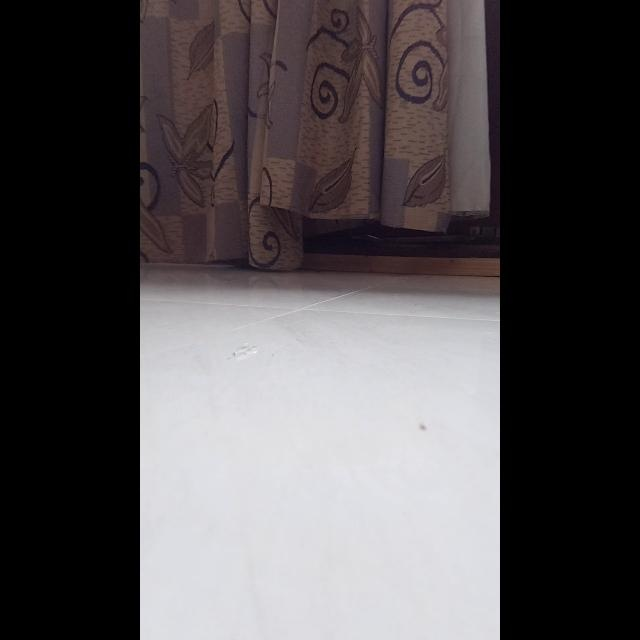

Results saved to /content/drive/.shortcut-targets-by-id/1R3aIHdYHPqNtSka0XaMebNOLm3nPE4Wj/GlassDetection_Official/runs/figure_colored__carpet

📸 Group: colored__carpet


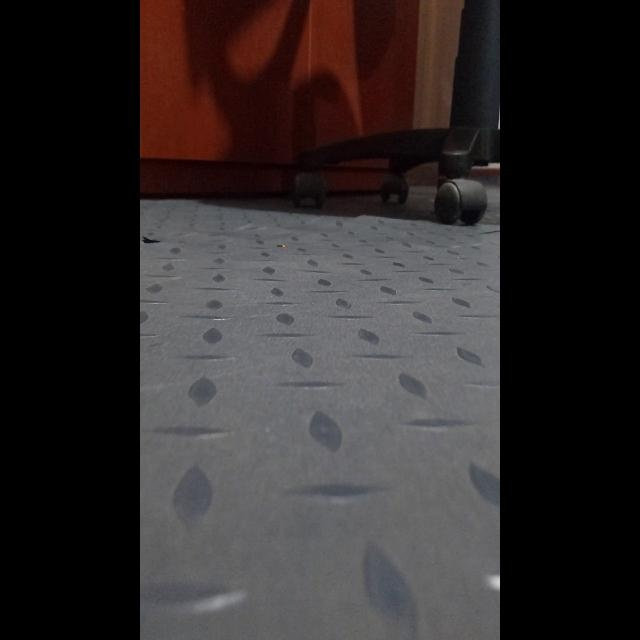

Results saved to /content/drive/.shortcut-targets-by-id/1R3aIHdYHPqNtSka0XaMebNOLm3nPE4Wj/GlassDetection_Official/runs/figure_colored__cement

📸 Group: colored__cement


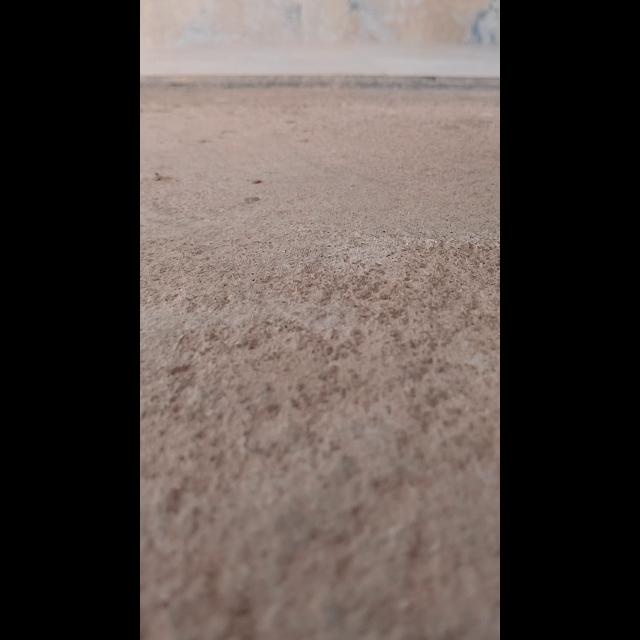

Results saved to /content/drive/.shortcut-targets-by-id/1R3aIHdYHPqNtSka0XaMebNOLm3nPE4Wj/GlassDetection_Official/runs/figure_colored__tile

📸 Group: colored__tile


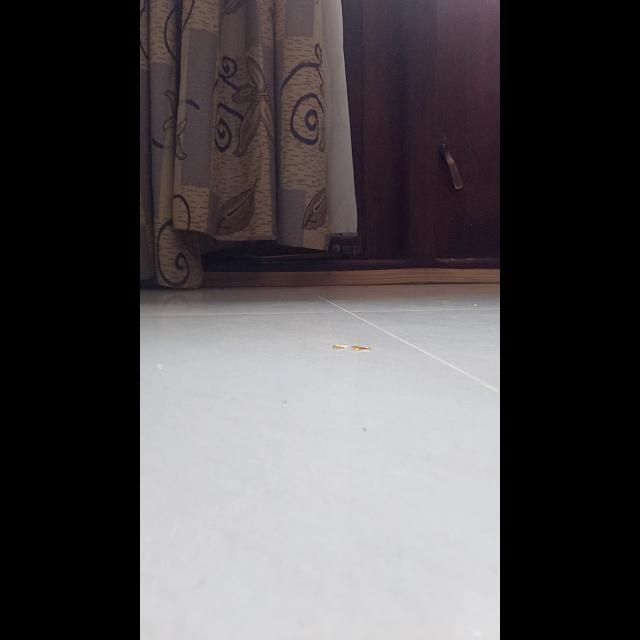


✅ All sample visualizations generated and saved in RUNS_DIR!


In [12]:
from ultralytics import YOLO
from IPython.display import Image as IPImage, display
import glob
import random
import os

RUNS_DIR = '/content/drive/MyDrive/GlassDetection_Official/runs'
SPLIT_BASE = '/content/drive/MyDrive/GlassDetection_Official/test_splits'

# Using the Baseline model since it performed better overall in the Ablation Study
# (If you prefer to show the CLAHE model's outputs, change this path to best_clahe.pt)
BEST_MODEL = '/content/drive/MyDrive/GlassDetection_Official/runs/glass_seg_v1_30/weights/best.pt'

print(f"Loading model for visualization: {BEST_MODEL}")
model = YOLO(BEST_MODEL)

# Pick one sample from each group for dissertation figures
for group in sorted(os.listdir(SPLIT_BASE)):
    img_dir = os.path.join(SPLIT_BASE, group, 'images')
    if not os.path.exists(img_dir):
        continue

    # Grab all jpg/png files
    images = glob.glob(os.path.join(img_dir, '*.jpg')) + glob.glob(os.path.join(img_dir, '*.png'))
    if not images:
        continue

    sample = random.choice(images)

    # Run inference and save the result
    result = model.predict(
        source  = sample,
        imgsz   = 640,
        conf    = 0.25,
        save    = True,
        project = RUNS_DIR,
        name    = f'figure_{group}',
        verbose = False
    )

    # Find the newly saved predicted image and display it
    saved_images = glob.glob(os.path.join(RUNS_DIR, f'figure_{group}', '*.*'))
    if saved_images:
        print(f'\n📸 Group: {group}')
        display(IPImage(saved_images[0], width=600))

print('\n✅ All sample visualizations generated and saved in RUNS_DIR!')